In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv('../artifacts/sentiment_analysis.csv')

In [3]:
tweets = [
    "good product",
    "very good product",
    "excellent phone",
    "excellent quality",
    "excellent service",
    "best camera",
    "best phone",
    "best product",
    "awesome performance",
    "awesome experience",
    "amazing phone",
    "amazing quality",
    "great phone",
    "great product",
    "great quality",
    "wonderful product",
    "wonderful experience",
    "fantastic product",
    "fantastic quality",
    "perfect product",
    "perfect quality",
    "brilliant phone",
    "super phone",
    "beautiful design",
    "love this phone",
    "love this product",
    "love it",
    "liked it",
    "highly recommended",
    "strongly recommended",
    "recommend this product",
    "worth buying",
    "worth every penny",
    "good value for money",
    "happy with this product",
    "very happy",
    "very satisfied",
    "highly satisfied",
    "impressive quality",
    "outstanding performance",
    "pleasant experience",
    "delightful experience",
    "smooth performance",
    "fast performance",
    "fast charging",
    "quick delivery",
    "reliable product",
    "useful product",
    "valuable product",
    "high quality product",
    "premium quality",
    "works perfectly",
    "works great",
    "five star product",
    "excellent choice",
    "good choice",
    "favorite phone",
    "favorite product",
    "success",
    "successful purchase",
    "absolutely amazing",
    "absolutely fantastic",
    "absolutely wonderful",
    "absolutely perfect",
    "easy to use",
    "very easy to use",
    "excellent support",
    "excellent customer service",
    "amazing display",
    "excellent display",
    "great battery backup",
    "excellent battery life",
    "beautiful interface",
    "awesome app",
    "great app",
    "best app"
]

new_data = pd.DataFrame({
    "tweet": tweets,
    "label": [0] * len(tweets)
})

data = pd.concat([data, new_data], ignore_index=True)

In [4]:
data.head()

,id,label,tweet
0,1.0,0,#fingerprint #Pregnancy Test https://goo.gl/h1...
1,2.0,0,Finally a transparant silicon case ^^ Thanks t...
2,3.0,0,We love this! Would you go? #talk #makememorie...
3,4.0,0,I'm wired I know I'm George I was made that wa...
4,5.0,1,What amazing service! Apple won't even talk to...


In [5]:
data.shape

(7996, 3)

In [6]:
data.duplicated().sum()

np.int64(0)

In [7]:
data.isnull().sum()

id       76
label     0
tweet     0
dtype: int64

In [8]:
#text preprocessing
#uppercase-->lowercase
#remove links
#remove punctuations
#remove numbers
#remove stopwords
#stemming


In [9]:
import re
import string

In [10]:
#uppercase--->lowercase

data["tweet"].head(5)

0    #fingerprint #Pregnancy Test https://goo.gl/h1...
1    Finally a transparant silicon case ^^ Thanks t...
2    We love this! Would you go? #talk #makememorie...
3    I'm wired I know I'm George I was made that wa...
4    What amazing service! Apple won't even talk to...
Name: tweet, dtype: str

In [11]:
data["tweet"] = data["tweet"].apply(
    lambda x: " ".join(x.lower() for x in x.split())
)

In [12]:
data["tweet"].head(5)

0    #fingerprint #pregnancy test https://goo.gl/h1...
1    finally a transparant silicon case ^^ thanks t...
2    we love this! would you go? #talk #makememorie...
3    i'm wired i know i'm george i was made that wa...
4    what amazing service! apple won't even talk to...
Name: tweet, dtype: str

In [13]:
#remove links

data["tweet"] = data["tweet"].apply(
    lambda x: " ".join(
        re.sub(r'^https?:\/\/.*[\r\n]*', '', x, flags=re.MULTILINE)
        for x in x.split()
    )
)

In [14]:
data["tweet"].head(5)

0    #fingerprint #pregnancy test  #android #apps #...
1    finally a transparant silicon case ^^ thanks t...
2    we love this! would you go? #talk #makememorie...
3    i'm wired i know i'm george i was made that wa...
4    what amazing service! apple won't even talk to...
Name: tweet, dtype: str

In [15]:
#remove punctuations

string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [16]:
def remove_punctuations(text):
    for punctuation in string.punctuation:
        text = text.replace(punctuation, '')
    return text

data["tweet"] = data["tweet"].apply(remove_punctuations)

In [17]:
data["tweet"].head(5)

0    fingerprint pregnancy test  android apps beaut...
1    finally a transparant silicon case  thanks to ...
2    we love this would you go talk makememories un...
3    im wired i know im george i was made that way ...
4    what amazing service apple wont even talk to m...
Name: tweet, dtype: str

In [18]:
#remove numbers

data["tweet"] = data["tweet"].str.replace('\d+', '', regex=True)

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_28400/246605985.py:3: SyntaxWarning: invalid escape sequence '\d'
  data["tweet"] = data["tweet"].str.replace('\d+', '', regex=True)


In [19]:
data["tweet"].tail(15)

7981          absolutely fantastic
7982          absolutely wonderful
7983            absolutely perfect
7984                   easy to use
7985              very easy to use
7986             excellent support
7987    excellent customer service
7988               amazing display
7989             excellent display
7990          great battery backup
7991        excellent battery life
7992           beautiful interface
7993                   awesome app
7994                     great app
7995                      best app
Name: tweet, dtype: str

In [20]:
!pip install nltk

In [21]:
import nltk

In [22]:
nltk.download('stopwords',download_dir='../static/model')

[nltk_data] Downloading package stopwords to ../static/model...
[nltk_data]   Package stopwords is already up-to-date!


True

In [23]:
import nltk
print(nltk.__version__)

3.10.0


In [24]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/manasa/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [25]:
with open('../static/model/corpora/stopwords/english', 'r') as file:
    sw = file.read().splitlines()

In [26]:
sw

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [27]:
data["tweet"] = data["tweet"].apply(
    lambda x: " ".join([x for x in x.split() if x not in sw])
)

In [28]:
data["tweet"].head()

0    fingerprint pregnancy test android apps beauti...
1    finally transparant silicon case thanks uncle ...
2    love would go talk makememories unplug relax i...
3    im wired know im george made way iphone cute d...
4    amazing service apple wont even talk question ...
Name: tweet, dtype: str

In [29]:
from nltk.stem import PorterStemmer

ps = PorterStemmer()

In [30]:
data["tweet"] = data["tweet"].apply(
    lambda x: " ".join(ps.stem(x) for x in x.split())
)

In [31]:
data

,id,label,tweet
0,1.0,0,fingerprint pregnanc test android app beauti c...
1,2.0,0,final transpar silicon case thank uncl yay son...
2,3.0,0,love would go talk makememori unplug relax iph...
3,4.0,0,im wire know im georg made way iphon cute dave...
4,5.0,1,amaz servic appl wont even talk question unles...
...,...,...,...
7991,NaN,0,excel batteri life
7992,NaN,0,beauti interfac
7993,NaN,0,awesom app
7994,NaN,0,great app


In [32]:
#building vocabulary

from collections import Counter

vocab = Counter()


In [33]:
vocab

Counter()

In [34]:
for sentence in data['tweet']:
    vocab.update(sentence.split())

In [35]:
vocab

Counter({'iphon': 4073,
         'appl': 2876,
         'samsung': 1395,
         'new': 1137,
         'phone': 1023,
         'follow': 885,
         'soni': 819,
         '…': 751,
         'ipad': 537,
         'rt': 525,
         'love': 502,
         'like': 456,
         'day': 426,
         'app': 419,
         'life': 416,
         'android': 414,
         'photo': 394,
         'get': 382,
         'io': 382,
         'galaxi': 361,
         'instagram': 358,
         'case': 348,
         'beauti': 324,
         'cute': 322,
         'gain': 311,
         'today': 309,
         'work': 308,
         'happi': 295,
         'im': 294,
         'back': 294,
         'fuck': 293,
         'photographi': 292,
         'game': 282,
         'got': 280,
         'fun': 277,
         'news': 265,
         'thank': 263,
         'music': 263,
         'time': 248,
         'make': 247,
         'updat': 236,
         'smile': 231,
         'instagood': 226,
         'funni': 223,
   

In [36]:
len(vocab)

15953

In [37]:
data.shape

(7996, 3)

In [38]:
tokens=[key for key in vocab if vocab[key]>10]

In [39]:
tokens

['test',
 'android',
 'app',
 'beauti',
 'cute',
 'health',
 'iger',
 'iphoneonli',
 'iphonesia',
 'iphon',
 'final',
 'case',
 'thank',
 'yay',
 'soni',
 'xperia',
 'love',
 'would',
 'go',
 'talk',
 'relax',
 'smartphon',
 'wifi',
 'connect',
 'im',
 'know',
 'made',
 'way',
 'home',
 'amaz',
 'servic',
 'appl',
 'wont',
 'even',
 'question',
 'pay',
 'stupid',
 'support',
 'softwar',
 'updat',
 'fuck',
 'phone',
 'big',
 'time',
 'happi',
 'us',
 'instap',
 'instadaili',
 'xperiaz',
 'new',
 'type',
 'c',
 'charger',
 'cabl',
 'uk',
 '…',
 'amazon',
 'year',
 'newyear',
 'start',
 'technolog',
 'samsunggalaxi',
 'iphonex',
 'shop',
 'listen',
 'music',
 'likeforlik',
 'photo',
 'fun',
 'selfi',
 'water',
 'camera',
 'picoftheday',
 'sun',
 'instagood',
 'boy',
 'outdoor',
 'hey',
 'make',
 'ipod',
 'dont',
 'color',
 'inch',
 'crash',
 'everi',
 'need',
 'realli',
 'drop',
 'ball',
 'design',
 'give',
 'anoth',
 'crazi',
 'purchas',
 'lol',
 'work',
 'hard',
 'play',
 'ipad',
 'batt

In [40]:
len(tokens)

1150

In [41]:
def save_vocabulary(lines, filename):
    data = '\n'.join(lines)
    file = open(filename, 'w', encoding='utf-8')
    file.write(data)
    file.close()

save_vocabulary(tokens, '../static/model/vocabulary.txt')

In [42]:
##dividing dataset



In [43]:
X=data['tweet']
y=data['label']

In [44]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [45]:
X_train.shape

(6396,)

In [46]:
X_test.shape

(1600,)

In [47]:
y_train.shape

(6396,)

In [48]:
#Vectorization code--->>

def vectorizer(ds, vocabulary):
    vectorized_lst = []

    for sentence in ds:
        sentence_lst = np.zeros(len(vocabulary))

        for i in range(len(vocabulary)):
            if vocabulary[i] in sentence.split():
                sentence_lst[i] = 1

        vectorized_lst.append(sentence_lst)

    vectorized_lst_new = np.asarray(vectorized_lst, dtype=np.float32)

    return vectorized_lst_new

In [49]:
vectorized_x_train = vectorizer(X_train, tokens)

In [50]:
for i in vectorized_x_train[0]:
    print(i)

0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


In [51]:
vectorized_x_test = vectorizer(X_test, tokens)

In [52]:
vectorized_x_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(6396, 1150), dtype=float32)

In [53]:
y_train

4859    0
3156    0
1306    0
6454    0
2285    1
       ..
854     0
2321    0
5318    1
7601    0
3245    0
Name: label, Length: 6396, dtype: int64

In [54]:
y_test

6337    0
5262    0
1273    0
2241    0
5205    0
       ..
4397    0
7280    1
1166    0
1523    1
5103    1
Name: label, Length: 1600, dtype: int64

In [55]:
y_train.value_counts()

label
0    4792
1    1604
Name: count, dtype: int64

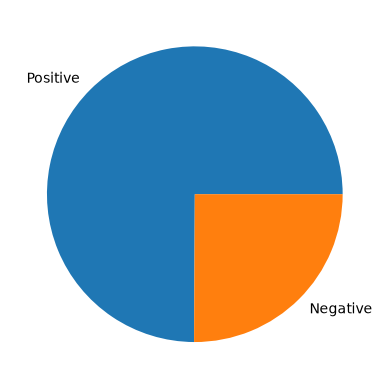

In [56]:
plt.pie(
    np.array([y_train.value_counts()[0], y_train.value_counts()[1]]),
    labels=['Positive', 'Negative']
)

plt.show()

In [57]:
!pip install imbalanced-learn

In [58]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()

vectorized_x_train_smote, y_train_smote = smote.fit_resample(
    vectorized_x_train,
    y_train
)

print(vectorized_x_train_smote.shape, y_train_smote.shape)

(9584, 1150) (9584,)


In [59]:
y_train_smote.value_counts()

label
0    4792
1    4792
Name: count, dtype: int64

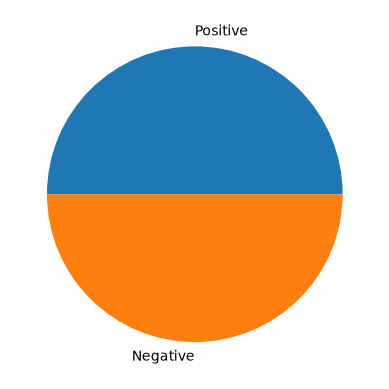

In [60]:
plt.pie(
    np.array([y_train_smote.value_counts()[0], y_train_smote.value_counts()[1]]),
    labels=['Positive', 'Negative']
)

plt.show()

In [61]:
y_train_smote

0       0
1       0
2       0
3       0
4       1
       ..
9579    1
9580    1
9581    1
9582    1
9583    1
Name: label, Length: 9584, dtype: int64

In [62]:
y_test

6337    0
5262    0
1273    0
2241    0
5205    0
       ..
4397    0
7280    1
1166    0
1523    1
5103    1
Name: label, Length: 1600, dtype: int64

In [63]:
#Model training and evaluation

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


In [64]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
def training_scores(y_act, y_pred):
    acc = round(accuracy_score(y_act, y_pred), 3)
    pr = round(precision_score(y_act, y_pred), 3)
    rec = round(recall_score(y_act, y_pred), 3)
    f1 = round(f1_score(y_act, y_pred), 3)

    print(f'Training Scores:\n\tAccuracy = {acc}\n\tPrecision = {pr}\n\tRecall = {rec}\n\tF1-Score = {f1}')

In [65]:
def validation_scores(y_act, y_pred):
    acc = round(accuracy_score(y_act, y_pred), 3)
    pr = round(precision_score(y_act, y_pred), 3)
    rec = round(recall_score(y_act, y_pred), 3)
    f1 = round(f1_score(y_act, y_pred), 3)

    print(f'Testing Scores:\n\tAccuracy = {acc}\n\tPrecision = {pr}\n\tRecall = {rec}\n\tF1-Score = {f1}')

In [66]:
##Logistic Regression----->

lr=LogisticRegression()
lr.fit(vectorized_x_train_smote,y_train_smote)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [67]:
y_train_pred=lr.predict(vectorized_x_train_smote)

In [68]:
y_train_pred

array([0, 1, 0, ..., 1, 1, 1], shape=(9584,))

In [69]:
y_train_smote

0       0
1       0
2       0
3       0
4       1
       ..
9579    1
9580    1
9581    1
9582    1
9583    1
Name: label, Length: 9584, dtype: int64

In [70]:
training_scores(y_train_smote,y_train_pred)

Training Scores:
	Accuracy = 0.941
	Precision = 0.918
	Recall = 0.969
	F1-Score = 0.943


In [82]:
y_test_pred

array([1, 0, 0, ..., 0, 1, 1], shape=(1600,))

In [83]:
validation_scores(y_test,y_test_pred)

Testing Scores:
	Accuracy = 0.874
	Precision = 0.748
	Recall = 0.789
	F1-Score = 0.768


In [76]:
#MultinomialNb






In [77]:
# Naive Bayes

mnb = MultinomialNB()

mnb.fit(vectorized_x_train_smote, y_train_smote)

y_train_pred = mnb.predict(vectorized_x_train_smote)

y_test_pred = mnb.predict(vectorized_x_test)

training_scores(y_train_smote, y_train_pred)

validation_scores(y_test, y_test_pred)


Training Scores:
	Accuracy = 0.907
	Precision = 0.867
	Recall = 0.96
	F1-Score = 0.912
Testing Scores:
	Accuracy = 0.866
	Precision = 0.683
	Recall = 0.915
	F1-Score = 0.782


In [78]:
# DecisionTree Classifier

dt = DecisionTreeClassifier()

dt.fit(vectorized_x_train_smote, y_train_smote)

y_train_pred = dt.predict(vectorized_x_train_smote)

y_test_pred = dt.predict(vectorized_x_test)

training_scores(y_train_smote, y_train_pred)

validation_scores(y_test, y_test_pred)




Training Scores:
	Accuracy = 1.0
	Precision = 1.0
	Recall = 1.0
	F1-Score = 1.0
Testing Scores:
	Accuracy = 0.833
	Precision = 0.697
	Recall = 0.649
	F1-Score = 0.672


In [79]:
#RandomforestClassifier

rf = RandomForestClassifier()

rf.fit(vectorized_x_train_smote, y_train_smote)

y_train_pred = rf.predict(vectorized_x_train_smote)

y_test_pred = rf.predict(vectorized_x_test)

training_scores(y_train_smote, y_train_pred)

validation_scores(y_test, y_test_pred)


Training Scores:
	Accuracy = 1.0
	Precision = 1.0
	Recall = 1.0
	F1-Score = 1.0
Testing Scores:
	Accuracy = 0.859
	Precision = 0.761
	Recall = 0.68
	F1-Score = 0.718


In [80]:
#SupportVectorMachine

svm = SVC()

svm.fit(vectorized_x_train_smote, y_train_smote)

y_train_pred = svm.predict(vectorized_x_train_smote)

y_test_pred = svm.predict(vectorized_x_test)

training_scores(y_train_smote, y_train_pred)

validation_scores(y_test, y_test_pred)


Training Scores:
	Accuracy = 0.979
	Precision = 0.963
	Recall = 0.996
	F1-Score = 0.98
Testing Scores:
	Accuracy = 0.874
	Precision = 0.748
	Recall = 0.789
	F1-Score = 0.768


In [81]:
import pickle


with open('../static/model/model.pickle','wb') as file:
    pickle.dump(lr,file)